In [43]:
# Bibliotecas gerais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utilidades
from time import perf_counter

# Divisão dos dados
from sklearn.model_selection import train_test_split

# Métricas de avaliação
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

ETAPA DE DADOS - Baixando a base de dados para a pasta raw

In [1]:
from sklearn.datasets import fetch_openml

print("Baixando o dataset MNIST...")

mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False,
    parser="auto",
    data_home="../data/raw"
)

print("Finalizou o download do dataset MNIST!")

Baixando o dataset MNIST...
Finalizou o download do dataset MNIST!


ETAPA DE ANÁLISE

In [3]:
X = mnist.data
y = mnist.target.astype(int)

print(f"Dimensões de X: {X.shape}")
print(f"Dimensões de y: {y.shape}")

classes, contagens = np.unique(y, return_counts=True)

distribuicao = pd.DataFrame({
    "Classe": classes,
    "Quantidade": contagens,
    "Percentual (%)": (contagens / len(y) * 100).round(2)
})

display(distribuicao)

diferenca = contagens.max() - contagens.min()
variacao_percentual = diferenca / contagens.max() * 100

print(f"Classes identificadas: {classes}")
print(f"Maior classe: {contagens.max()} exemplos")
print(f"Menor classe: {contagens.min()} exemplos")
print(f"Diferença: {diferenca} exemplos")
print(f"Variação entre maior e menor classe: {variacao_percentual:.2f}%")

Dimensões de X: (70000, 784)
Dimensões de y: (70000,)


,Classe,Quantidade,Percentual (%)
0,0,6903,9.86
1,1,7877,11.25
2,2,6990,9.99
3,3,7141,10.20
4,4,6824,9.75
5,5,6313,9.02
6,6,6876,9.82
7,7,7293,10.42
8,8,6825,9.75
9,9,6958,9.94


Classes identificadas: [0 1 2 3 4 5 6 7 8 9]
Maior classe: 7877 exemplos
Menor classe: 6313 exemplos
Diferença: 1564 exemplos
Variação entre maior e menor classe: 19.86%


Conclusão: O conjunto contém todas as classes esperadas, representando os dígitos de 0 a 9. Embora exista uma variação de 19,86% entre a classe mais e a menos frequente, nenhuma classe apresenta baixa representatividade. Portanto, o dataset pode ser considerado suficientemente balanceado, não sendo necessário aplicar técnicas de reamostragem. Por meio da estratificação essa distribuição será preservada.

ETAPA - Criar visualização dos dados

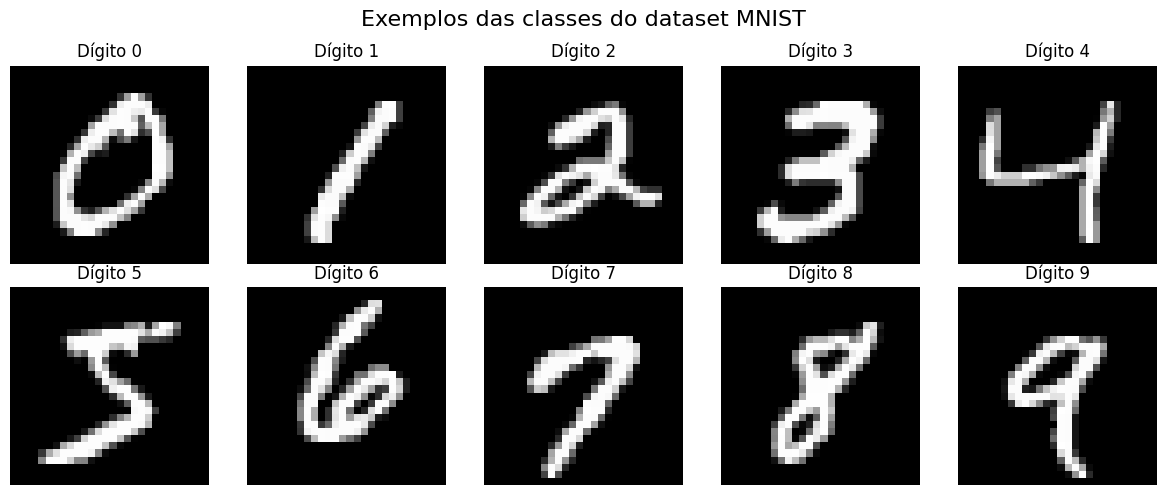

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for classe, eixo in zip(classes, axes.ravel()):
    indice = np.flatnonzero(y == classe)[0]
    imagem = X[indice].reshape(28, 28)

    eixo.imshow(imagem, cmap="gray")
    eixo.set_title(f"Dígito {classe}")
    eixo.axis("off")

fig.suptitle("Exemplos das classes do dataset MNIST", fontsize=16)
plt.tight_layout()
plt.show()

Conclusão : A visualização confirma que cada registro de X, armazenado como um vetor de 784 atributos, pode ser reorganizado em uma matriz de 28 × 28 pixels, reconstruindo a imagem original do dígito. A escala de cinza permite representar a intensidade de cada pixel com um único valor, reduzindo a complexidade dos dados sem perder as características essenciais do formato do dígito (se tivesse mais cores haveria a necessidade de camadas chamadas canais). Enquanto o formato matricial facilita a interpretação visual, o vetor de 784 pixels é a representação utilizada como entrada pelos modelos de classificação.

Cada pixel do MNIST possui um valor entre 0 e 255. O valor 0 representa o fundo preto, 255 representa o branco com intensidade máxima e os valores intermediários representam diferentes tons de cinza.

ETAPA - Pré processamento

In [7]:
RANDOM_STATE = 42

# Primeira divisão: 80% desenvolvimento e 20% teste
X_dev, X_test, y_dev, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Segunda divisão: 70% treino e 10% validação
X_train, X_val, y_train, y_val = train_test_split(
    X_dev,
    y_dev,
    test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=y_dev
)

print(f"Treino:    X={X_train.shape} | y={y_train.shape}")
print(f"Validação: X={X_val.shape} | y={y_val.shape}")
print(f"Teste:     X={X_test.shape} | y={y_test.shape}")

distribuicao_splits = pd.DataFrame({
    "Treino (%)": pd.Series(y_train).value_counts(normalize=True).sort_index() * 100,
    "Validação (%)": pd.Series(y_val).value_counts(normalize=True).sort_index() * 100,
    "Teste (%)": pd.Series(y_test).value_counts(normalize=True).sort_index() * 100
}).round(2)

distribuicao_splits.index.name = "Classe"

display(distribuicao_splits)

Treino:    X=(49000, 784) | y=(49000,)
Validação: X=(7000, 784) | y=(7000,)
Teste:     X=(14000, 784) | y=(14000,)


,Treino (%),Validação (%),Teste (%)
Classe,,,
0,9.86,9.86,9.86
1,11.25,11.26,11.25
2,9.99,9.99,9.99
3,10.20,10.20,10.20
4,9.75,9.74,9.75
5,9.02,9.01,9.02
6,9.82,9.83,9.82
7,10.42,10.41,10.42
8,9.75,9.76,9.75


Conclusão: A divisão resultou em 49.000 exemplos para treinamento (70%), 7.000 para validação (10%) e 14.000 para teste (20%). O uso da estratificação preservou praticamente as mesmas proporções das dez classes nos três conjuntos, com diferenças máximas de aproximadamente 0,02 ponto percentual. Isso permite treinar, ajustar e avaliar os modelos em conjuntos representativos e reduz o risco de resultados influenciados por diferenças na distribuição das classes.

In [9]:
X_train = X_train.astype(np.float32) / 255.0
X_val = X_val.astype(np.float32) / 255.0
X_test = X_test.astype(np.float32) / 255.0

for nome, conjunto in {
    "Treino": X_train,
    "Validação": X_val,
    "Teste": X_test
}.items():
    print(
        f"{nome}: tipo={conjunto.dtype} | "
        f"mínimo={conjunto.min():.1f} | "
        f"máximo={conjunto.max():.1f}"
    )

Treino: tipo=float32 | mínimo=0.0 | máximo=1.0
Validação: tipo=float32 | mínimo=0.0 | máximo=1.0
Teste: tipo=float32 | mínimo=0.0 | máximo=1.0


A normalização converteu os pixels da escala original de 0–255 para o intervalo de 0–1, preservando proporcionalmente suas intensidades. A conversão para float32 permite representar os valores decimais resultantes e reduz o consumo de memória em comparação com float64.

A divisão dos dados foi realizada antes da normalização, mantendo separados os conjuntos de treino, validação e teste. Como a transformação consiste apenas na divisão por uma constante fixa (255), nenhum parâmetro foi calculado a partir dos dados de validação ou teste. Portanto, não houve vazamento de informações entre os conjuntos.

ETAPA MODELOS

Com os dados separados em conjuntos de treinamento, validação e teste, serão avaliados três algoritmos de classificação: K-Nearest Neighbors (KNN), Random Forest e Multilayer Perceptron (MLP). Cada modelo será treinado com o conjunto de treinamento e terá seus hiperparâmetros analisados com o conjunto de validação. Após a seleção das melhores configurações, o desempenho final será medido no conjunto de teste, permitindo comparar a capacidade de generalização e o custo computacional dos modelos.


ETAPA MODELOS - KNN

In [11]:
def treinar_avaliar_knn(
    X_train,
    y_train,
    X_val,
    y_val,
    n_neighbors=5,
    weights="uniform"
):
    modelo = KNeighborsClassifier(
        n_neighbors=n_neighbors,
        weights=weights
    )

    inicio_treino = perf_counter()
    modelo.fit(X_train, y_train)
    tempo_treino = perf_counter() - inicio_treino

    inicio_predicao = perf_counter()
    y_pred = modelo.predict(X_val)
    tempo_predicao = perf_counter() - inicio_predicao

    acuracia = accuracy_score(y_val, y_pred)

    resultados = {
        "n_neighbors": n_neighbors,
        "weights": weights,
        "tempo_treino_segundos": tempo_treino,
        "tempo_predicao_segundos": tempo_predicao,
        "acuracia_validacao": acuracia
    }

    return modelo, y_pred, resultados


knn_inicial, y_pred_knn, resultados_knn = treinar_avaliar_knn(
    X_train,
    y_train,
    X_val,
    y_val
)

for metrica, valor in resultados_knn.items():
    print(f"{metrica}: {valor}")

n_neighbors: 5
weights: uniform
tempo_treino_segundos: 0.05471009999746457
tempo_predicao_segundos: 10.670730099984212
acuracia_validacao: 0.9694285714285714


O KNN inicial, com n_neighbors=5 e pesos uniformes, alcançou 96,94% de acurácia no conjunto de validação.

O treinamento foi muito rápido (0,05 s), enquanto a predição levou 10,67 s. O resultado apresenta boa acurácia inicial, mas evidencia maior custo computacional.

In [19]:
print(pd.DataFrame(resultados_knn).columns.tolist())

['n_neighbors', 'weights', 'tempo_treino_segundos', 'tempo_predicao_segundos', 'acuracia_validacao']


In [18]:
resultados_knn = []

for n_neighbors in [3, 5, 7]:
    for weights in ["uniform", "distance"]:
        _, _, resultado = treinar_avaliar_knn(
            X_train,
            y_train,
            X_val,
            y_val,
            n_neighbors=n_neighbors,
            weights=weights
        )

        resultados_knn.append(resultado)

comparacao_knn = (
    pd.DataFrame(resultados_knn)
    .sort_values(
        by=["acuracia_validacao", "tempo_predicao_segundos"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(comparacao_knn)

melhor_configuracao_knn = comparacao_knn.iloc[0]

print(
    f"Melhor configuração: "
    f"n_neighbors={melhor_configuracao_knn['n_neighbors']} | "
    f"weights={melhor_configuracao_knn['weights']} | "
    f"acurácia={melhor_configuracao_knn['acuracia_validacao']:.4f}"
)

,n_neighbors,weights,tempo_treino_segundos,tempo_predicao_segundos,acuracia_validacao
0,3,distance,0.026084,5.841733,0.972286
1,3,uniform,0.043076,5.652625,0.971857
2,5,distance,0.030899,5.899764,0.971429
3,7,distance,0.027426,6.542986,0.969857
4,5,uniform,0.026426,5.747065,0.969429
5,7,uniform,0.028663,6.176123,0.968429


Melhor configuração: n_neighbors=3 | weights=distance | acurácia=0.9723


In [ ]:
resultados_knn = []

for n_neighbors in [3, 5, 7]:
    for weights in ["uniform", "distance"]:
        _, y_pred, resultado = treinar_avaliar_knn(
            X_train,
            y_train,
            X_val,
            y_val,
            n_neighbors=n_neighbors,
            weights=weights
        )

        resultado["f1_macro"] = f1_score(
            y_val,
            y_pred,
            average="macro"
        )

        resultados_knn.append(resultado)

comparacao_knn = (
    pd.DataFrame(resultados_knn)
    .sort_values(
        by=["f1_macro", "acuracia_validacao"],
        ascending=[False, False]
    )
    .reset_index(drop=True)
)

display(comparacao_knn)

melhor_configuracao_knn = comparacao_knn.iloc[0]



,n_neighbors,weights,tempo_treino_segundos,tempo_predicao_segundos,acuracia_validacao,f1_macro
0,3,distance,0.026139,5.328244,0.972286,0.972215
1,3,uniform,0.037132,5.312728,0.971857,0.971775
2,5,distance,0.024302,5.135344,0.971429,0.971464
3,7,distance,0.026569,5.172869,0.969857,0.969896
4,5,uniform,0.025828,5.181702,0.969429,0.969386
5,7,uniform,0.037088,5.120130,0.968429,0.968422


Melhor configuração: n_neighbors=3 | weights=distance | acurácia=0.9723F1=0.9722


In [27]:
print(
    f"Melhor configuração: "
    f"n_neighbors={melhor_configuracao_knn['n_neighbors']} | "
    f"weights={melhor_configuracao_knn['weights']} | "
    f"acurácia={melhor_configuracao_knn['acuracia_validacao']}  | "
    f"F1={melhor_configuracao_knn['f1_macro']:.4f}"
)

Melhor configuração: n_neighbors=3 | weights=distance | acurácia=0.9722857142857143  | F1=0.9722


Conclusão: Os resultados indicam que a melhor configuração do KNN utiliza n_neighbors=3 e weights="distance", alcançando 97,23% de acurácia e 97,22% de F1-score macro no conjunto de validação. A ponderação pela distância apresentou desempenho superior aos pesos uniformes em todos os valores de n_neighbors, indicando que os vizinhos mais próximos fornecem informações mais relevantes para a classificação.

A proximidade entre a acurácia e o F1-score macro demonstra que o desempenho do modelo está distribuído de forma relativamente equilibrada entre as dez classes, sem favorecer apenas os dígitos mais frequentes. As duas métricas produzem o mesmo ordenamento das configurações e confirmam a seleção de n_neighbors=3 e weights="distance" para representar o KNN na comparação final com os demais modelos.

ETAPA 3 - Randomm forest

In [29]:
def treinar_avaliar_random_forest(
    X_train,
    y_train,
    X_val,
    y_val,
    n_estimators=100,
    max_depth=None,
    random_state=42
):
    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=random_state,
        n_jobs=-1
    )

    inicio_treino = perf_counter()
    modelo.fit(X_train, y_train)
    tempo_treino = perf_counter() - inicio_treino

    inicio_predicao = perf_counter()
    y_pred = modelo.predict(X_val)
    tempo_predicao = perf_counter() - inicio_predicao

    resultado = {
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "tempo_treino_segundos": tempo_treino,
        "tempo_predicao_segundos": tempo_predicao,
        "acuracia_validacao": accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(y_val, y_pred, average="macro")
    }

    return modelo, y_pred, resultado


modelo_rf, y_pred_rf, resultado_rf = treinar_avaliar_random_forest(
    X_train,
    y_train,
    X_val,
    y_val
)

for metrica, valor in resultado_rf.items():
    print(f"{metrica}: {valor}")

n_estimators: 100
max_depth: None
tempo_treino_segundos: 11.100197299994761
tempo_predicao_segundos: 0.11613830001442693
acuracia_validacao: 0.9661428571428572
f1_macro: 0.9659752036619358


O modelo inicial de Random Forest, utilizando 100 estimadores e sem limitação de profundidade (max_depth=None), apresentou acurácia de 96,61% e F1-macro de 96,60% no conjunto de validação. Os valores muito próximos entre acurácia e F1-macro indicam um desempenho equilibrado entre as classes, sem que a avaliação dependa apenas da taxa global de acertos.

O treinamento levou aproximadamente 11,10 segundos, enquanto a predição foi realizada em cerca de 0,12 segundo, demonstrando baixo custo de inferência após o treinamento.

Esses resultados estabelecem uma linha de base (baseline) para o Random Forest. 

In [32]:
resultados_rf = []

valores_n_estimators = [100, 200]
valores_max_depth = [15, 25, None]

for n_estimators in valores_n_estimators:
    for max_depth in valores_max_depth:

        modelo_rf, y_pred_rf, resultado_rf = treinar_avaliar_random_forest(
            X_train,
            y_train,
            X_val,
            y_val,
            n_estimators=n_estimators,
            max_depth=max_depth
        )

        resultados_rf.append(resultado_rf)

resultados_rf = pd.DataFrame(resultados_rf)

resultados_rf

,n_estimators,max_depth,tempo_treino_segundos,tempo_predicao_segundos,acuracia_validacao,f1_macro
0,100,15.0,8.134774,0.111368,0.963000,0.962822
1,100,25.0,8.884165,0.092416,0.965143,0.964890
2,100,NaN,9.575910,0.108275,0.966143,0.965975
3,200,15.0,15.777941,0.201512,0.965429,0.965263
4,200,25.0,17.634053,0.186263,0.966143,0.965881
5,200,NaN,18.571413,0.172462,0.968000,0.967828


Foram avaliadas seis combinações de hiperparâmetros da Random Forest, utilizando 100 e 200 estimadores e valores de `max_depth` iguais a 15, 25 e sem limitação (`None`).

A configuração com 200 estimadores e `max_depth=None`** apresentou o melhor desempenho, alcançando 96,80% de acurácia e F1-macro de 96,78%. A melhor configuração com 100 estimadores também utilizou `max_depth=None`, obtendo 96,61% de acurácia e F1-macro de 96,60%.

O aumento de 100 para 200 estimadores sem limitação de profundidade resultou em um ganho de aproximadamente 0,19 ponto percentual tanto na acurácia quanto no F1-macro. Em contrapartida, o tempo de treinamento aumentou de aproximadamente 9,58 para 18,57 segundos, praticamente dobrando, enquanto o tempo de predição passou de aproximadamente 0,11 para 0,17 segundo.

Também foi possível observar que limitar a profundidade das árvores reduziu o custo computacional, mas apresentou resultados ligeiramente inferiores. Dessa forma, existe um trade-off entre desempenho e custo: 200 estimadores com `max_depth=None` apresentam o melhor desempenho preditivo, enquanto 100 estimadores com `max_depth=None` oferecem uma alternativa com desempenho muito próximo e menor custo computacional.

Para as próximas etapas do projeto, será adotada a configuração de 200 estimadores e `max_depth=None`, por apresentar os maiores valores de acurácia e F1-macro entre as configurações avaliadas.

ETAPA 3 - MLP 

In [34]:
def treinar_avaliar_mlp(
    X_train,
    y_train,
    X_val,
    y_val,
    hidden_layer_sizes=(100,),
    max_iter=200,
    random_state=42
):
    modelo = MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        max_iter=max_iter,
        random_state=random_state
    )

    inicio_treino = perf_counter()

    modelo.fit(
        X_train,
        y_train
    )

    tempo_treino = perf_counter() - inicio_treino

    inicio_predicao = perf_counter()

    y_pred = modelo.predict(X_val)

    tempo_predicao = perf_counter() - inicio_predicao

    resultado = {
        "arquitetura": hidden_layer_sizes,
        "max_iter": max_iter,
        "iteracoes_realizadas": modelo.n_iter_,
        "convergiu": modelo.n_iter_ < max_iter,
        "tempo_treino_segundos": tempo_treino,
        "tempo_predicao_segundos": tempo_predicao,
        "acuracia_validacao": accuracy_score(y_val, y_pred),
        "f1_macro": f1_score(
            y_val,
            y_pred,
            average="macro"
        )
    }

    return modelo, y_pred, resultado

In [36]:
modelo_mlp, y_pred_mlp, resultado_mlp = treinar_avaliar_mlp(
    X_train,
    y_train,
    X_val,
    y_val
)

for metrica, valor in resultado_mlp.items():
    print(f"{metrica}: {valor}")

arquitetura: (100,)
max_iter: 200
iteracoes_realizadas: 61
convergiu: True
tempo_treino_segundos: 34.75894410000183
tempo_predicao_segundos: 0.010937899991404265
acuracia_validacao: 0.9768571428571429
f1_macro: 0.9767055194093894


A MLP inicial foi configurada com uma camada oculta de 100 neurônios e limite máximo de 200 iterações. O treinamento foi concluído em 61 iterações, indicando que o modelo convergiu antes de atingir o limite definido.

No conjunto de validação, a MLP alcançou 97,69% de acurácia e F1-macro de 97,67%, demonstrando desempenho equilibrado entre as classes. O tempo de treinamento foi de aproximadamente 34,76 segundos, enquanto a predição foi realizada em cerca de 0,01 segundo.

Esses resultados estabelecem uma baseline forte para a MLP. Apesar do maior custo de treinamento em relação aos modelos anteriores, a rede apresentou excelente desempenho preditivo e baixo tempo de inferência, justificando a continuidade dos testes com diferentes arquiteturas e hiperparâmetros.

In [37]:
resultados_mlp = []

arquiteturas = [
    (50,),
    (100,),
    (100, 50)
]

for arquitetura in arquiteturas:

    modelo_mlp, y_pred_mlp, resultado_mlp = treinar_avaliar_mlp(
        X_train,
        y_train,
        X_val,
        y_val,
        hidden_layer_sizes=arquitetura,
        max_iter=200
    )

    resultados_mlp.append(resultado_mlp)

resultados_mlp = pd.DataFrame(resultados_mlp)

resultados_mlp

,arquitetura,max_iter,iteracoes_realizadas,convergiu,tempo_treino_segundos,tempo_predicao_segundos,acuracia_validacao,f1_macro
0,"(50,)",200,92,True,29.491870,0.014769,0.969000,0.968773
1,"(100,)",200,61,True,32.247741,0.014818,0.976857,0.976706
2,"(100, 50)",200,47,True,29.508519,0.015658,0.975143,0.975014


As três arquiteturas avaliadas apresentaram convergência antes do limite de 200 iterações, indicando que o número máximo definido foi suficiente para todos os experimentos.

A arquitetura com 50 neurônios em uma única camada oculta convergiu em 92 iterações e alcançou 96,90% de acurácia e F1-macro de 96,88%. A configuração com 100 neurônios em uma única camada oculta convergiu em 61 iterações e apresentou o melhor desempenho, com 97,69% de acurácia e F1-macro de 97,67%.

A arquitetura com duas camadas ocultas de 100 e 50 neurônios convergiu em 47 iterações, porém apresentou 97,51% de acurácia e F1-macro de 97,50%, não superando a configuração com uma única camada de 100 neurônios.

Os tempos de treinamento e predição permaneceram próximos entre as três configurações. Dessa forma, a arquitetura (100,) foi selecionada como a melhor configuração da MLP entre as alternativas avaliadas, pois apresentou os maiores valores de acurácia e F1-macro, sem evidenciar problemas de convergências.

ETAPA 4 - Avaliação

KNN usando n_neighbors=3 e weights="distance"

In [38]:
melhor_knn = KNeighborsClassifier(
    n_neighbors=3,
    weights="distance"
)

melhor_knn.fit(X_train, y_train)

y_pred_knn_test = melhor_knn.predict(X_test)

In [39]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_knn = accuracy_score(
    y_test,
    y_pred_knn_test
)

precision_knn = precision_score(
    y_test,
    y_pred_knn_test,
    average="weighted"
)

recall_knn = recall_score(
    y_test,
    y_pred_knn_test,
    average="weighted"
)

f1_knn = f1_score(
    y_test,
    y_pred_knn_test,
    average="weighted"
)

print(f"Accuracy:  {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall:    {recall_knn:.4f}")
print(f"F1-score:  {f1_knn:.4f}")

Accuracy:  0.9721
Precision: 0.9724
Recall:    0.9721
F1-score:  0.9721


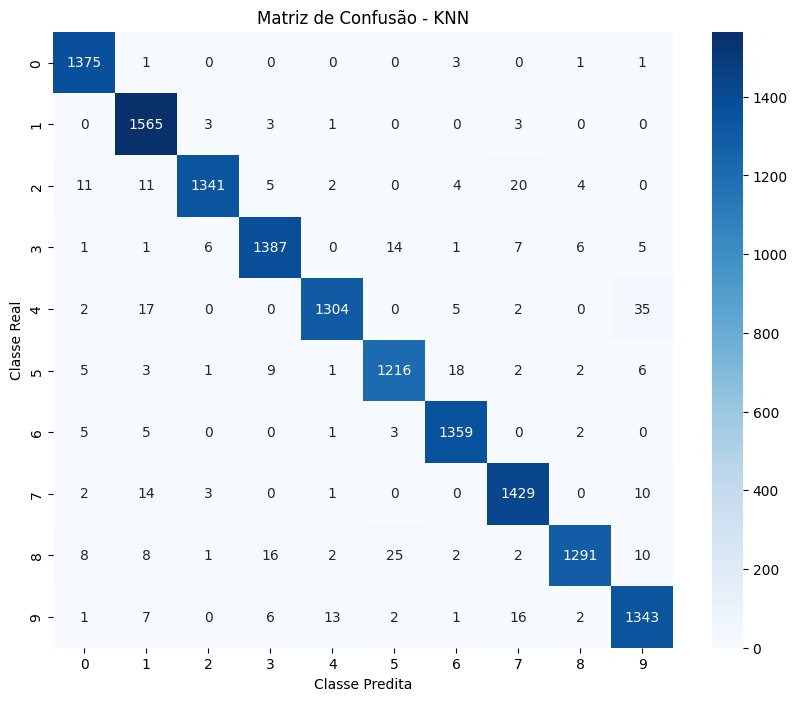

In [41]:
matriz_confusao_knn = confusion_matrix(
    y_test,
    y_pred_knn_test
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_confusao_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Matriz de Confusão - KNN")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

Conclusão: O KNN, utilizando a configuração selecionada de 3 vizinhos (n_neighbors=3) e pesos por distância (weights="distance"), apresentou 97,21% de acurácia, 97,24% de precisão, 97,21% de recall e 97,21% de F1-score ponderado no conjunto de teste. A proximidade entre as métricas indica um desempenho consistente do classificador.

A matriz de confusão apresenta forte concentração de valores na diagonal principal, demonstrando que a maioria das imagens foi corretamente classificada. Entre os erros mais frequentes, destacam-se as classificações do dígito 4 como 9 (35 casos), do 8 como 5 (25 casos) e do 2 como 7 (20 casos). Essas confusões podem estar relacionadas à similaridade visual entre determinados padrões de escrita desses dígitos.

De forma geral, o KNN apresentou bom desempenho e estabilidade no conjunto de teste, com poucos erros em relação ao total de 14.000 imagens avaliadas.

Avaliação do modelo Random forest

Dados utilizados n_estimators=200 e max_depth=None

In [42]:
melhor_random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

melhor_random_forest.fit(
    X_train,
    y_train
)

y_pred_rf_test = melhor_random_forest.predict(X_test)

In [44]:
#CALCULAR AS MÉTRICAS

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf_test
)

precision_rf = precision_score(
    y_test,
    y_pred_rf_test,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf_test,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf_test,
    average="weighted"
)

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-score:  {f1_rf:.4f}")

Accuracy:  0.9666
Precision: 0.9666
Recall:    0.9666
F1-score:  0.9666


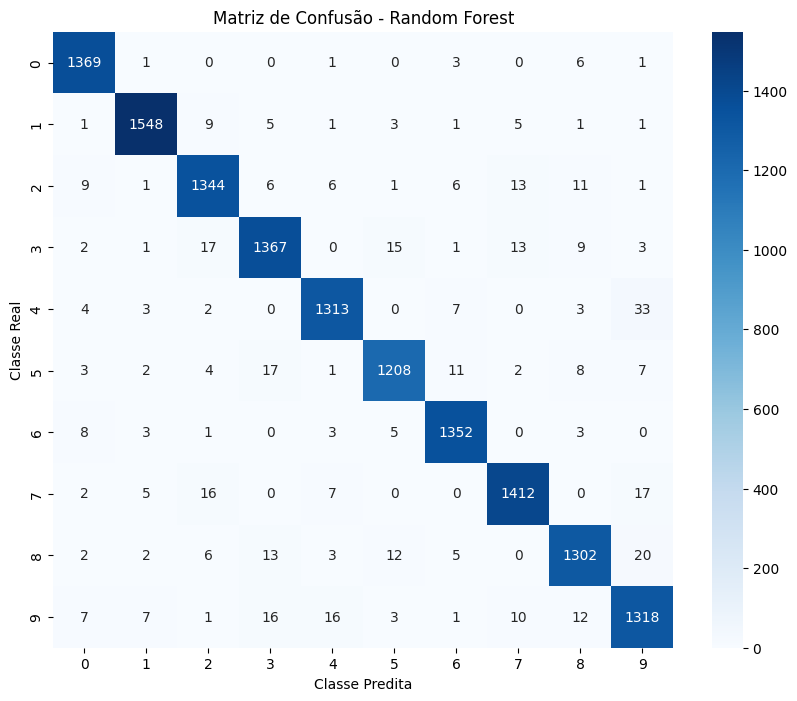

In [45]:
matriz_confusao_rf = confusion_matrix(
    y_test,
    y_pred_rf_test
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_confusao_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

A Random Forest, utilizando 200 estimadores (n_estimators=200) e sem limitação de profundidade (max_depth=None), apresentou 96,66% de acurácia, precisão, recall e F1-score ponderado no conjunto de teste. A proximidade entre as métricas indica um desempenho consistente na classificação das diferentes classes do MNIST.

A matriz de confusão apresenta forte concentração dos resultados na diagonal principal, indicando que a maior parte das imagens foi corretamente classificada. Entre os erros mais frequentes, destacam-se as classificações do dígito 4 como 9 (33 casos), do 8 como 9 (20 casos) e do 5 como 3 (17 casos). Também ocorreram 17 casos do dígito 3 classificado como 2 e 17 casos do dígito 7 classificado como 9.

De forma geral, a Random Forest apresentou bom desempenho no conjunto de teste, com aproximadamente 96,7% das 14.000 imagens classificadas corretamente. A matriz também evidencia que os erros estão distribuídos entre diferentes pares de dígitos, com algumas confusões mais frequentes entre padrões visualmente semelhantes.

AVALIAÇÃO MLP

Parâmetros usados hidden_layer_sizes=(100,), max_iter=200 e random_state=42

In [46]:
melhor_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=200,
    random_state=42
)

melhor_mlp.fit(
    X_train,
    y_train
)

y_pred_mlp_test = melhor_mlp.predict(X_test)

In [47]:
accuracy_mlp = accuracy_score(
    y_test,
    y_pred_mlp_test
)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp_test,
    average="weighted"
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp_test,
    average="weighted"
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp_test,
    average="weighted"
)

print(f"Accuracy:  {accuracy_mlp:.4f}")
print(f"Precision: {precision_mlp:.4f}")
print(f"Recall:    {recall_mlp:.4f}")
print(f"F1-score:  {f1_mlp:.4f}")


Accuracy:  0.9777
Precision: 0.9777
Recall:    0.9777
F1-score:  0.9777


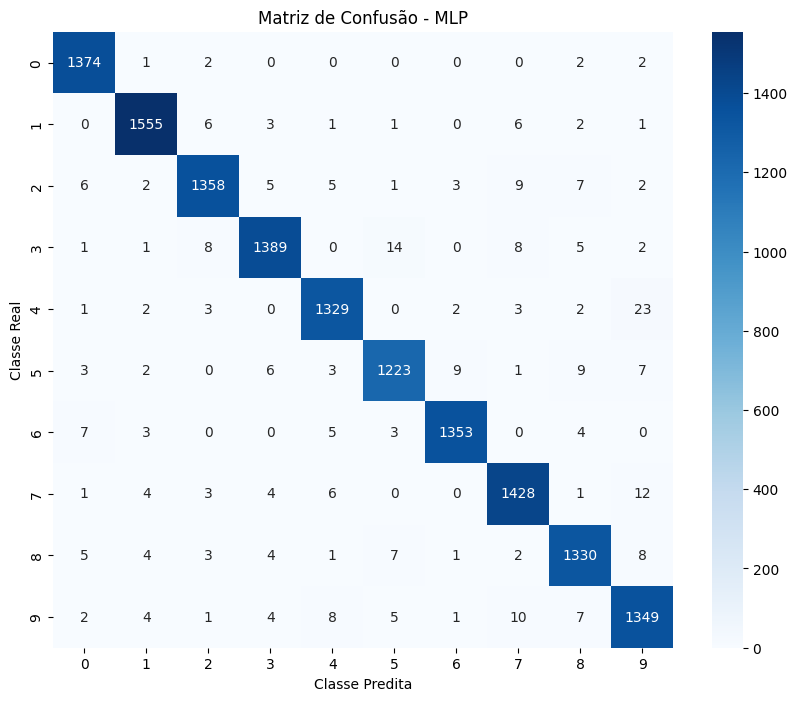

In [48]:
matriz_confusao_mlp = confusion_matrix(
    y_test,
    y_pred_mlp_test
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    matriz_confusao_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=range(10),
    yticklabels=range(10)
)

plt.title("Matriz de Confusão - MLP")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")

plt.show()

A MLP, utilizando a arquitetura selecionada de uma camada oculta com 100 neurônios (hidden_layer_sizes=(100,)) e limite máximo de 200 iterações, apresentou 97,77% de acurácia, precisão, recall e F1-score ponderado no conjunto de teste. A proximidade entre as métricas indica um desempenho consistente na classificação das dez classes do MNIST.

A matriz de confusão apresenta forte concentração dos resultados na diagonal principal, demonstrando que a grande maioria das imagens foi corretamente classificada. Entre os erros mais frequentes, destacam-se as classificações do dígito 4 como 9 (23 casos), do 3 como 5 (14 casos) e do 7 como 9 (12 casos). Também ocorreram 10 casos do dígito 9 classificado como 7.

De forma geral, a MLP apresentou bom desempenho e estabilidade no conjunto de teste, com aproximadamente 97,8% das 14.000 imagens classificadas corretamente. A matriz de confusão mostra ainda que os erros estão distribuídos entre diferentes classes, com maior incidência em alguns pares de dígitos que podem apresentar características visuais semelhantes.

Comparação dos três modelos

In [49]:
inicio_treino = perf_counter()
melhor_knn.fit(X_train, y_train)
tempo_treino_knn = perf_counter() - inicio_treino

inicio_predicao = perf_counter()
y_pred_knn_test = melhor_knn.predict(X_test)
tempo_predicao_knn = perf_counter() - inicio_predicao

In [50]:
inicio_treino = perf_counter()
melhor_random_forest.fit(X_train, y_train)
tempo_treino_rf = perf_counter() - inicio_treino

inicio_predicao = perf_counter()
y_pred_rf_test = melhor_random_forest.predict(X_test)
tempo_predicao_rf = perf_counter() - inicio_predicao

In [51]:
inicio_treino = perf_counter()
melhor_mlp.fit(X_train, y_train)
tempo_treino_mlp = perf_counter() - inicio_treino

inicio_predicao = perf_counter()
y_pred_mlp_test = melhor_mlp.predict(X_test)
tempo_predicao_mlp = perf_counter() - inicio_predicao

TABELA COMPARATIVA

In [52]:
comparacao_modelos = pd.DataFrame({
    "modelo": [
        "KNN",
        "Random Forest",
        "MLP"
    ],
    "accuracy": [
        accuracy_knn,
        accuracy_rf,
        accuracy_mlp
    ],
    "precision_weighted": [
        precision_knn,
        precision_rf,
        precision_mlp
    ],
    "recall_weighted": [
        recall_knn,
        recall_rf,
        recall_mlp
    ],
    "f1_weighted": [
        f1_knn,
        f1_rf,
        f1_mlp
    ],
    "tempo_treino_segundos": [
        tempo_treino_knn,
        tempo_treino_rf,
        tempo_treino_mlp
    ],
    "tempo_predicao_segundos": [
        tempo_predicao_knn,
        tempo_predicao_rf,
        tempo_predicao_mlp
    ]
})

In [53]:
comparacao_modelos = comparacao_modelos.sort_values(
    by="f1_weighted",
    ascending=False
).reset_index(drop=True)

comparacao_modelos

,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted,tempo_treino_segundos,tempo_predicao_segundos
0,MLP,0.977714,0.977742,0.977714,0.977713,37.082660,0.040500
1,KNN,0.972143,0.972371,0.972143,0.972110,0.118094,16.094465
2,Random Forest,0.966643,0.966649,0.966643,0.966627,24.634135,0.496136


Conclusão — Comparação dos modelos

Os três modelos apresentaram bom desempenho na classificação dos dígitos do MNIST, com F1-score ponderado superior a 96% em todos os casos.

A MLP apresentou o melhor desempenho geral, alcançando 97,77% de acurácia e 97,77% de F1-score ponderado. Apesar de apresentar o maior tempo de treinamento, aproximadamente 37,08 segundos, realizou a predição das 14.000 imagens em apenas 0,04 segundo, combinando o melhor desempenho preditivo com baixo custo de inferência.

O KNN apresentou o segundo melhor resultado, com 97,21% de acurácia e 97,21% de F1-score ponderado. Seu treinamento foi extremamente rápido, cerca de 0,12 segundo, porém apresentou o maior tempo de predição, aproximadamente 16,09 segundos. Esse comportamento é característico do KNN, que armazena os dados durante o treinamento e concentra grande parte do custo computacional no momento da classificação.

A Random Forest obteve 96,66% de acurácia e 96,66% de F1-score ponderado, com aproximadamente 24,63 segundos de treinamento e 0,50 segundo de predição. Embora apresente inferência mais rápida que o KNN, obteve o menor desempenho preditivo entre as três configurações avaliadas.

Considerando conjuntamente as métricas de classificação e o custo de inferência, a MLP com uma camada oculta de 100 neurônios foi selecionada como o modelo final. Além de apresentar os maiores valores de accuracy, precision, recall e F1-score ponderado, também apresentou o menor tempo de predição entre os modelos avaliados.

Dígito com mais erros em cada modelo

In [59]:
modelos_predicoes = {
    "KNN": y_pred_knn_test,
    "Random Forest": y_pred_rf_test,
    "MLP": y_pred_mlp_test
}

erros_por_modelo = {}

for modelo, y_pred in modelos_predicoes.items():

    erros_por_classe = []

    for classe in range(10):
        mascara_classe = y_test == classe

        quantidade_erros = np.sum(
            y_pred[mascara_classe] != y_test[mascara_classe]
        )

        erros_por_classe.append(quantidade_erros)

    erros_por_modelo[modelo] = erros_por_classe

tabela_erros = pd.DataFrame(
    erros_por_modelo,
    index=range(10)
)

tabela_erros.index.name = "digito"

tabela_erros["Total"] = tabela_erros.sum(axis=1)

tabela_erros

,KNN,Random Forest,MLP,Total
digito,,,,
0,6,12,7,25
1,10,27,20,57
2,57,54,40,151
3,41,61,39,141
4,61,52,36,149
5,47,55,40,142
6,16,23,22,61
7,30,47,31,108
8,74,63,35,172


In [55]:
for modelo in tabela_erros.columns:
    digito = tabela_erros[modelo].idxmax()
    quantidade = tabela_erros[modelo].max()

    print(
        f"{modelo}: dígito {digito} "
        f"com {quantidade} erros"
    )

KNN: dígito 8 com 74 erros
Random Forest: dígito 9 com 73 erros
MLP: dígito 9 com 42 erros


Encontrar os pares de dígitos mais confundidos

In [56]:
for modelo, y_pred in modelos_predicoes.items():

    matriz = confusion_matrix(
        y_test,
        y_pred
    )

    matriz_sem_diagonal = matriz.copy()
    np.fill_diagonal(matriz_sem_diagonal, 0)

    classe_real, classe_predita = np.unravel_index(
        np.argmax(matriz_sem_diagonal),
        matriz_sem_diagonal.shape
    )

    quantidade = matriz_sem_diagonal[
        classe_real,
        classe_predita
    ]

    print(
        f"{modelo}: {classe_real} → {classe_predita} "
        f"({quantidade} casos)"
    )

KNN: 4 → 9 (35 casos)
Random Forest: 4 → 9 (33 casos)
MLP: 4 → 9 (23 casos)


Mostrar exemplos classificados incorretamente

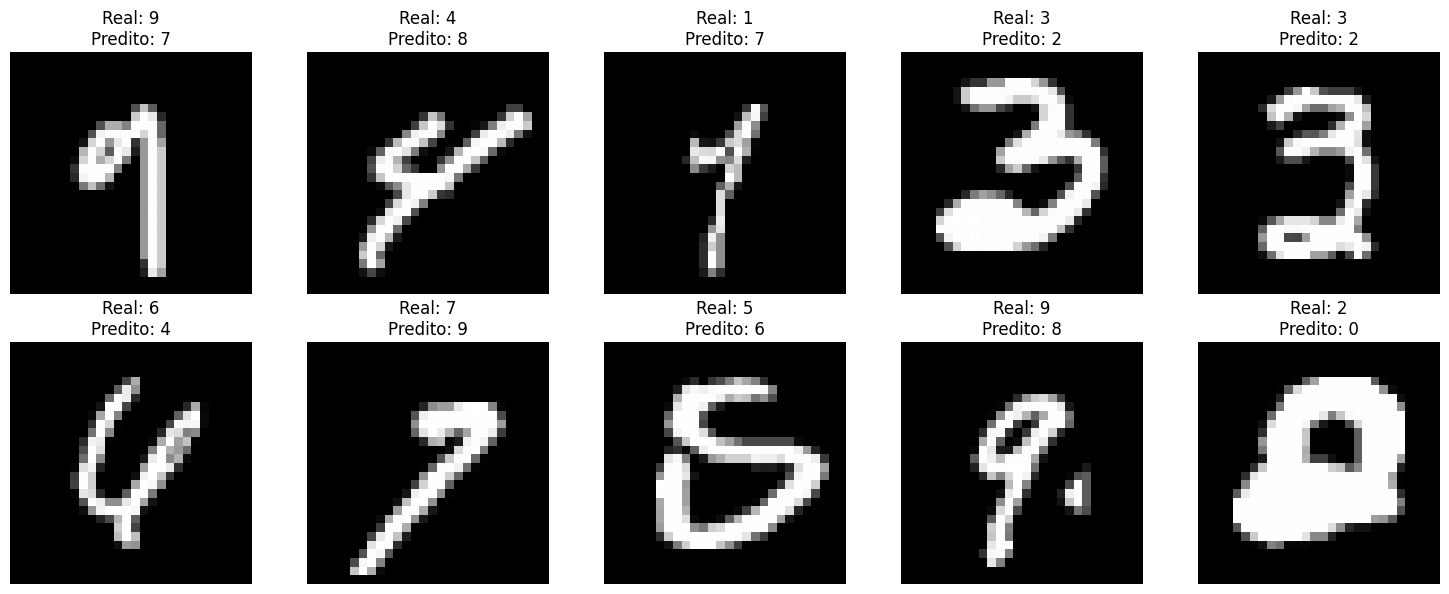

In [57]:
indices_erros = np.where(
    y_pred_mlp_test != y_test
)[0]

plt.figure(figsize=(15, 6))

for i, indice in enumerate(indices_erros[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[indice].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Real: {y_test[indice]}\n"
        f"Predito: {y_pred_mlp_test[indice]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Como o erro mais comum foi 4 sendo confundido por 9, a seguir seguem alguns exemplos

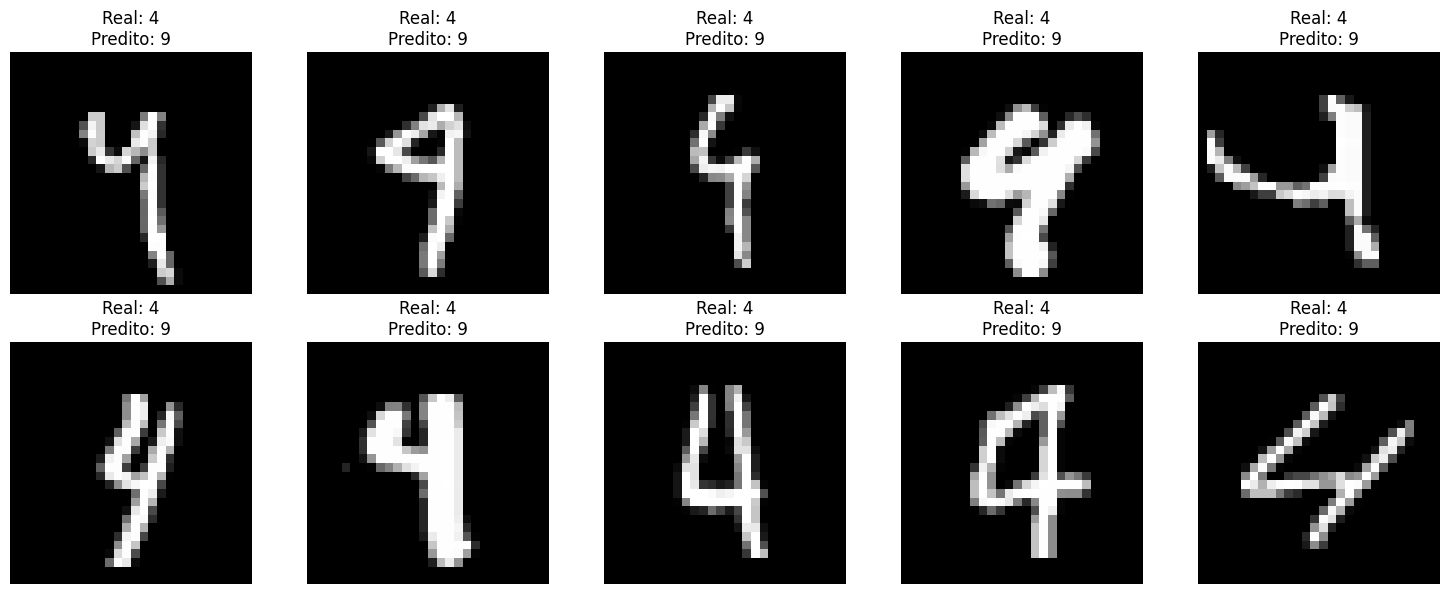

In [60]:
indices_4_como_9 = np.where(
    (y_test == 4) &
    (y_pred_mlp_test == 9)
)[0]

plt.figure(figsize=(15, 6))

for i, indice in enumerate(indices_4_como_9[:10]):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test[indice].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Real: {y_test[indice]}\n"
        f"Predito: {y_pred_mlp_test[indice]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

A análise mostrou que os modelos apresentam diferentes quantidades de erros por classe, sendo os dígitos 8 e 9 alguns dos mais difíceis de classificar.

O principal padrão de confusão foi o mesmo nos três modelos: o dígito 4 classificado como 9, ocorrendo 35 vezes no KNN, 33 na Random Forest e 23 na MLP. A recorrência desse erro sugere que determinadas formas de escrita desses dígitos apresentam características visuais semelhantes, dificultando sua classificação.

EXPERIMENTO DE CLASSES OCULTAS

Nesta etapa será avaliada a robustez dos modelos diante de dados diferentes daqueles utilizados no treinamento. Para simular uma situação Out-of-Distribution, serão aplicadas perturbações controladas nas imagens do conjunto de teste, mantendo seus respectivos rótulos.

O objetivo é verificar quanto o desempenho dos modelos se degrada quando as imagens apresentam pequenas alterações visuais, como ruído ou deslocamento. Os modelos não serão retreinados com esses dados modificados, permitindo avaliar sua capacidade de generalização diante de uma mudança na distribuição dos dados.

Com base nos resultados até agora iremos usar como classes ocultas 4 e 9, usando o modelo MLP e vamos verificar como o modelo se comporta quando encontra classes que não participaram do treinamento.

In [ ]:
classes_ocultas = [4, 9]

mascara_ocultas = np.isin(
    y_train,
    classes_ocultas
)

X_train_oculto = X_train[mascara_ocultas]
y_train_oculto = y_train[mascara_ocultas]

X_train_sem_ocultas = X_train[~mascara_ocultas] #inverte a seleção anterior
y_train_sem_ocultas = y_train[~mascara_ocultas] #inverte a seleção anterior

In [62]:
print(f"Treino original: {len(y_train)}")
print(f"Classes ocultas: {len(y_train_oculto)}")
print(f"Treino sem classes ocultas: {len(y_train_sem_ocultas)}")

print(
    "Classes utilizadas no treinamento:",
    np.unique(y_train_sem_ocultas)
)

print(
    "Classes ocultas:",
    np.unique(y_train_oculto)
)

Treino original: 49000
Classes ocultas: 9648
Treino sem classes ocultas: 39352
Classes utilizadas no treinamento: [0 1 2 3 5 6 7 8]
Classes ocultas: [4 9]


Separação no teste

In [63]:
mascara_test_ocultas = np.isin(
    y_test,
    classes_ocultas
)

X_test_ocultas = X_test[mascara_test_ocultas]
y_test_ocultas = y_test[mascara_test_ocultas]

X_test_conhecidas = X_test[~mascara_test_ocultas]
y_test_conhecidas = y_test[~mascara_test_ocultas]

In [64]:
print(
    "Classes conhecidas:",
    np.unique(y_test_conhecidas)
)

print(
    "Classes ocultas:",
    np.unique(y_test_ocultas)
)

print(
    f"Teste conhecido: {len(y_test_conhecidas)} imagens"
)

print(
    f"Teste oculto: {len(y_test_ocultas)} imagens"
)

Classes conhecidas: [0 1 2 3 5 6 7 8]
Classes ocultas: [4 9]
Teste conhecido: 11244 imagens
Teste oculto: 2756 imagens


Treinar a MLP sem as classes ocultas

In [65]:
mlp_sem_ocultas = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=200,
    random_state=42
)

inicio_treino = perf_counter()

mlp_sem_ocultas.fit(
    X_train_sem_ocultas,
    y_train_sem_ocultas
)

tempo_treino_mlp_sem_ocultas = perf_counter() - inicio_treino

print(f"Tempo de treinamento: {tempo_treino_mlp_sem_ocultas:.2f} segundos")
print(f"Iterações realizadas: {mlp_sem_ocultas.n_iter_}")
print(f"Convergiu: {mlp_sem_ocultas.n_iter_ < mlp_sem_ocultas.max_iter}")
print(f"Classes aprendidas: {mlp_sem_ocultas.classes_}")

Tempo de treinamento: 30.26 segundos
Iterações realizadas: 60
Convergiu: True
Classes aprendidas: [0 1 2 3 5 6 7 8]


A MLP foi treinada sem exemplos das classes 4 e 9, utilizando apenas os dígitos 0, 1, 2, 3, 5, 6, 7 e 8. O treinamento foi concluído em aproximadamente 30,26 segundos, com convergência após 60 iterações, antes do limite máximo de 200.

A verificação das classes aprendidas confirma que 4 e 9 não participaram do treinamento, garantindo que possam ser utilizados posteriormente como classes ocultas no experimento de robustez OOD.

In [72]:
print("Classes presentes:", np.unique(y_test_ocultas))
print("Quantidade de imagens:", len(y_test_ocultas))

Classes presentes: [4 9]
Quantidade de imagens: 2756


Fazer o modelo prever 4 e 9

In [73]:
y_pred_ocultas = mlp_sem_ocultas.predict(
    X_test_ocultas
)

print(
    "Classes atribuídas pelo modelo:",
    np.unique(y_pred_ocultas)
)

Classes atribuídas pelo modelo: [0 1 2 3 5 6 7 8]


In [74]:
tabela_ocultas = pd.crosstab(
    y_test_ocultas,
    y_pred_ocultas,
    rownames=["Classe real"],
    colnames=["Classe atribuída"]
)

tabela_ocultas

Classe atribuída,0,1,2,3,5,6,7,8
Classe real,,,,,,,,
4,31,31,130,44,74,93,554,408
9,27,21,6,117,59,5,1000,156


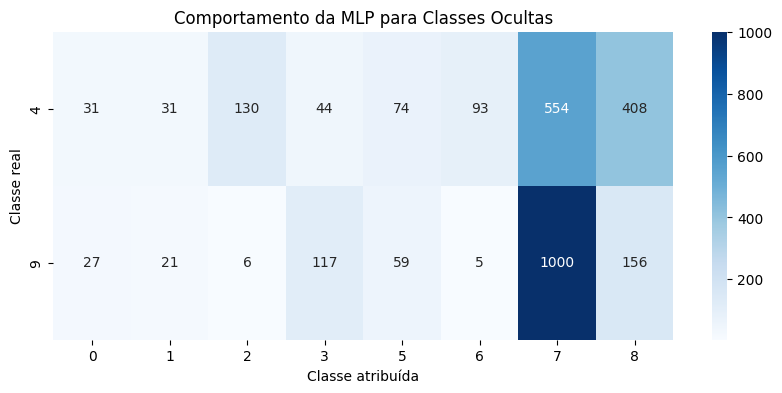

In [75]:
plt.figure(figsize=(10, 4))

sns.heatmap(
    tabela_ocultas,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Comportamento da MLP para Classes Ocultas")
plt.xlabel("Classe atribuída")
plt.ylabel("Classe real")

plt.show()

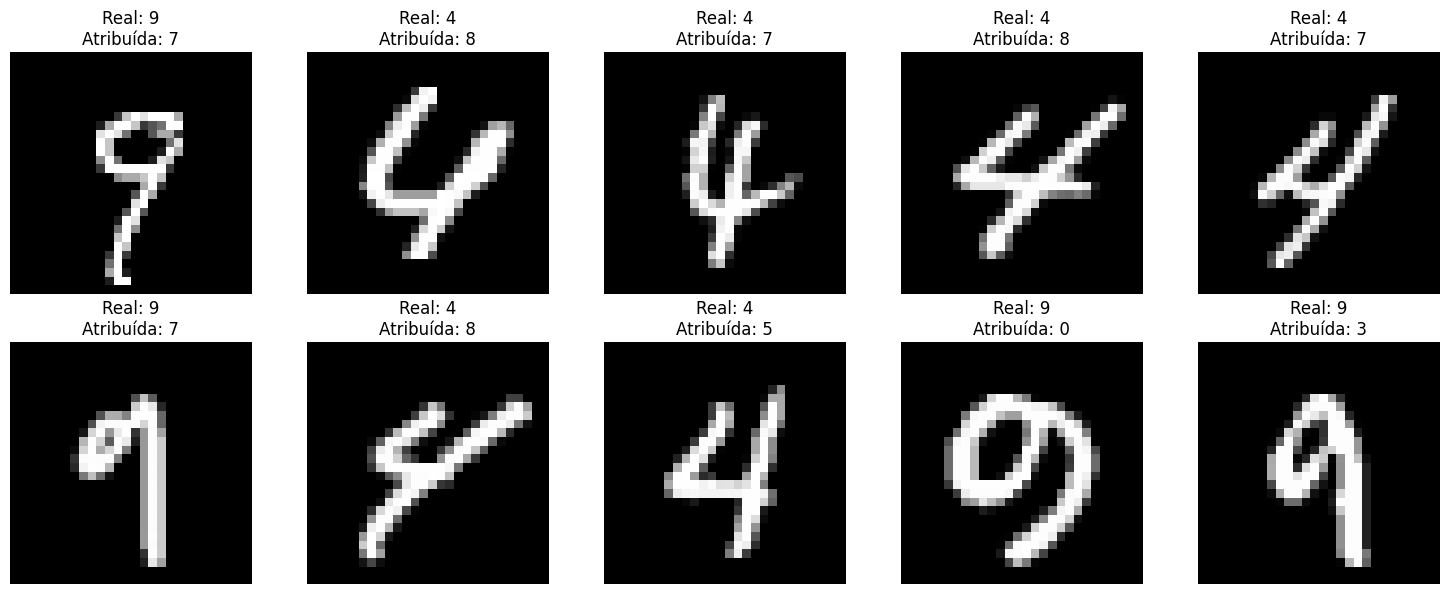

In [76]:
plt.figure(figsize=(15, 6))

for i in range(10):

    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_test_ocultas[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Real: {y_test_ocultas[i]}\n"
        f"Atribuída: {y_pred_ocultas[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

Com base nos resultados faço uma análise sobre a falsa certeza

In [77]:
probabilidades_ocultas = mlp_sem_ocultas.predict_proba(
    X_test_ocultas
)

probabilidade_maxima = probabilidades_ocultas.max(axis=1)

classe_atribuida = mlp_sem_ocultas.classes_[
    probabilidades_ocultas.argmax(axis=1)
]

In [78]:
tabela_falsa_certeza = pd.DataFrame({
    "classe_real": y_test_ocultas,
    "classe_atribuida": classe_atribuida,
    "probabilidade_maxima": probabilidade_maxima
})

tabela_falsa_certeza.head(10)

,classe_real,classe_atribuida,probabilidade_maxima
0,9,7,0.992322
1,4,8,0.632484
2,4,7,0.999993
3,4,8,0.999977
4,4,7,0.964369
5,9,7,0.999922
6,4,8,0.999996
7,4,5,0.827700
8,9,0,0.422598
9,9,3,0.716654


In [79]:
for limite in [0.80, 0.90, 0.95, 0.99]:

    quantidade = np.sum(
        probabilidade_maxima >= limite
    )

    percentual = (
        quantidade /
        len(probabilidade_maxima)
    ) * 100

    print(
        f"Probabilidade >= {limite:.0%}: "
        f"{quantidade} ({percentual:.2f}%)"
    )

Probabilidade >= 80%: 2189 (79.43%)
Probabilidade >= 90%: 1924 (69.81%)
Probabilidade >= 95%: 1696 (61.54%)
Probabilidade >= 99%: 1287 (46.70%)


In [80]:
tabela_falsa_certeza.groupby(
    "classe_real"
)["probabilidade_maxima"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
])

,count,mean,median,min,max
classe_real,,,,,
4,1365,0.879294,0.967326,0.293174,1.0
9,1391,0.920431,0.993284,0.360046,1.0


O experimento demonstrou que a MLP pode apresentar alta confiança ao classificar dados pertencentes a classes que nunca foram utilizadas em seu treinamento. Entre as 2.756 imagens das classes ocultas 4 e 9, 79,43% receberam uma classificação com probabilidade igual ou superior a 80%, enquanto 69,81% apresentaram probabilidade superior a 90%. Esse comportamento ocorre porque o modelo não possui uma classe “desconhecido”. Assim, ao receber uma imagem de 4 ou 9, precisa atribuí-la a uma das oito classes conhecidas, mesmo quando nenhuma delas representa corretamente a entrada.

Os resultados demonstram que alta probabilidade de predição não é suficiente para garantir confiabilidade diante de dados fora da distribuição de treinamento, evidenciando uma limitação importante do modelo em cenários OOD.